Étape 1 : Téléchargement des données en cours...


[*********************100%***********************]  15 of 15 completed


Étape 2 : Formatage du tableau...
Étape 3 : Réorganisation et nettoyage (IQR)...
Étape 4 : Sauvegarde du fichier final dans la session Colab...
Données prêtes !
MEILLEURS ACTIFS
Actif 1: Stock_10 (p-value: 0.0037)
Actif 2: Stock_8 (p-value: 0.0196)
Actif 3: Stock_7 (p-value: 0.1334)
Actif 4: Stock_13 (p-value: 0.1830)
Actif 5: Stock_1 (p-value: 0.2636)
Beta:1.0000
Beta:0.1496
Beta:0.1764
Beta:0.1905
Beta:0.0816
Beta:0.0441
START DATE:  2020-01-02
END DATE:  2025-12-30
# of days:  2189
Restricted license - for non-production use only - expires 2027-11-29

========== RÉSULTATS POUR PORTEFEUILLE TOTAL ==========
            KPI Stratégie Buy & Hold
           CAGR   12.34 %    11.86 %
   Max Drawdown   41.68 %    50.09 %
Ratio de Sharpe      0.26       0.24
Ratio de Calmar      0.30       0.24
   Total Trades        19          -


========== RÉSULTATS POUR Future ==========
            KPI Stratégie Buy & Hold
           CAGR   -2.20 %    -2.16 %
   Max Drawdown   30.34 %    60.32 %
Rati

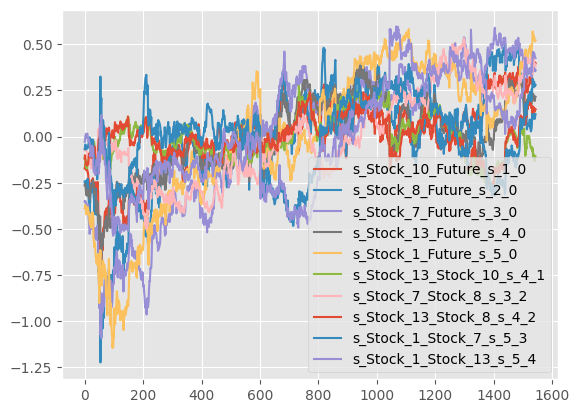

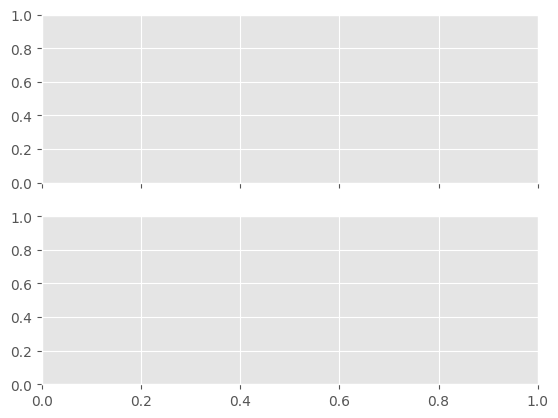

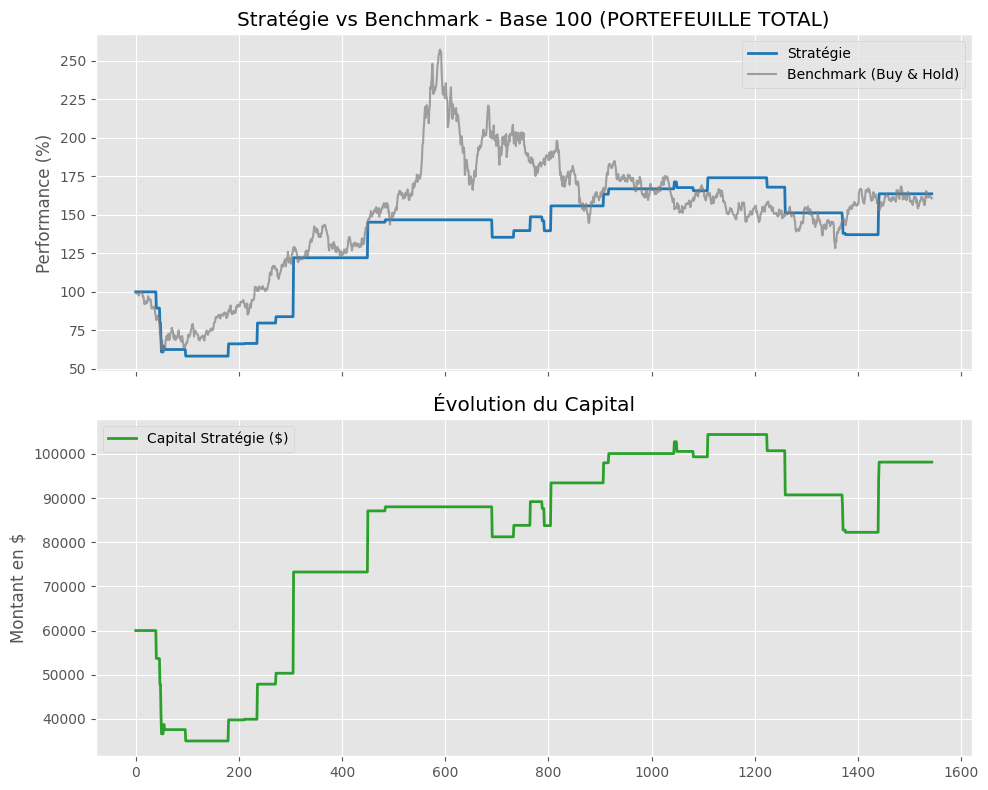

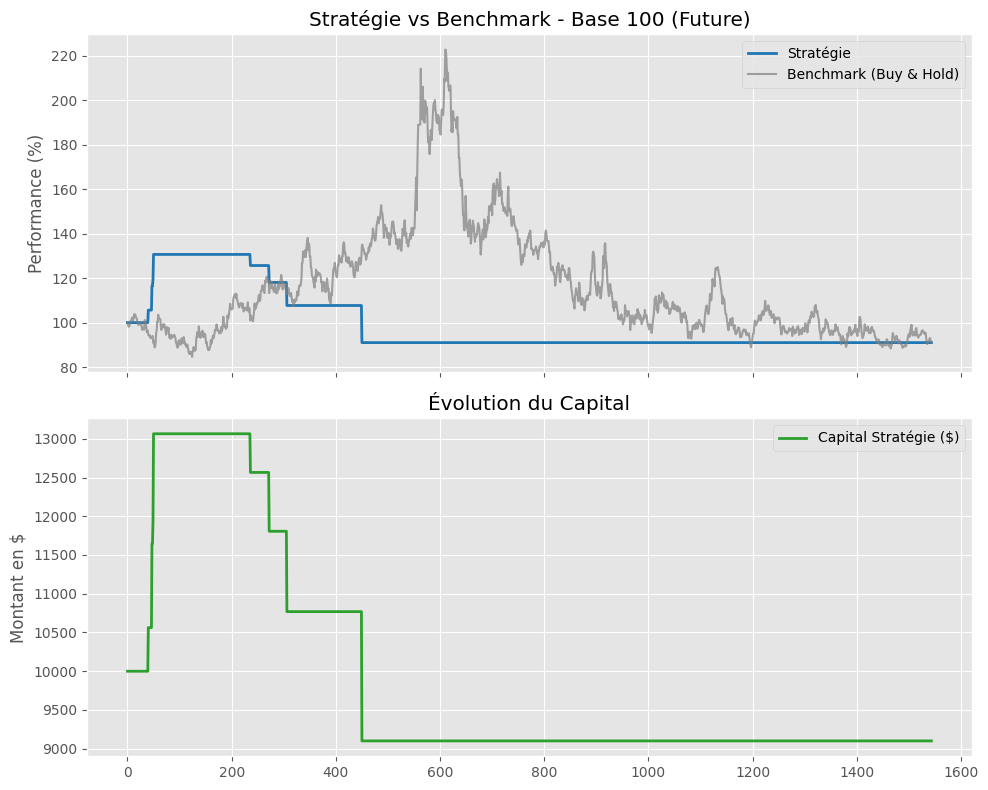

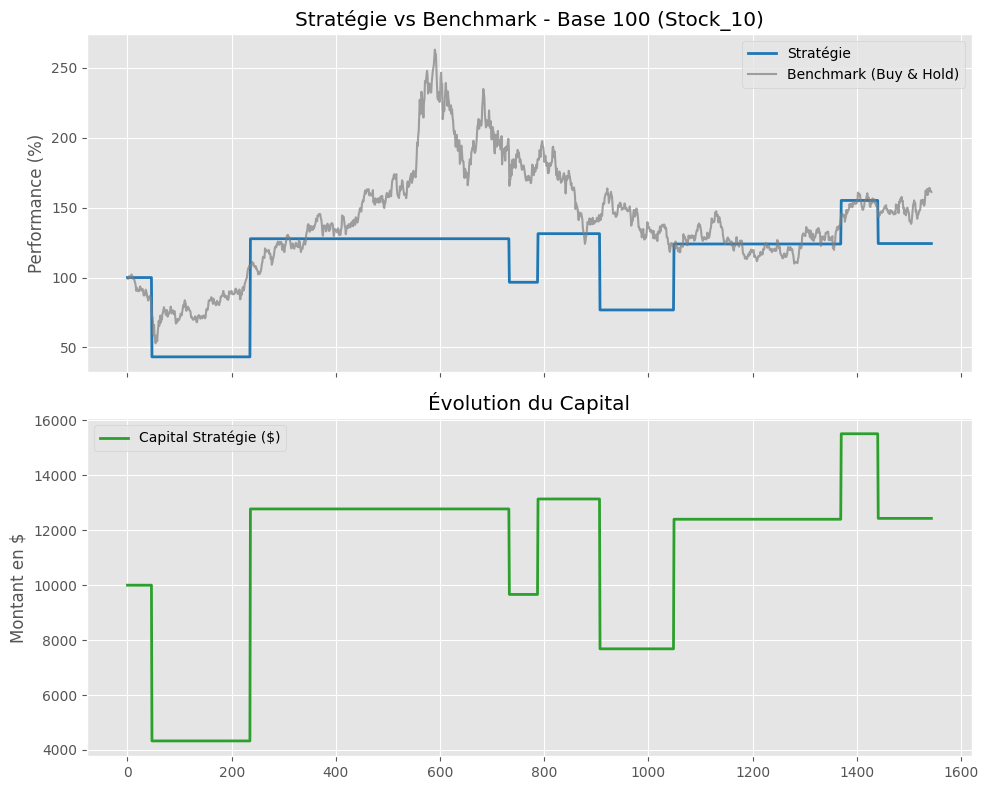

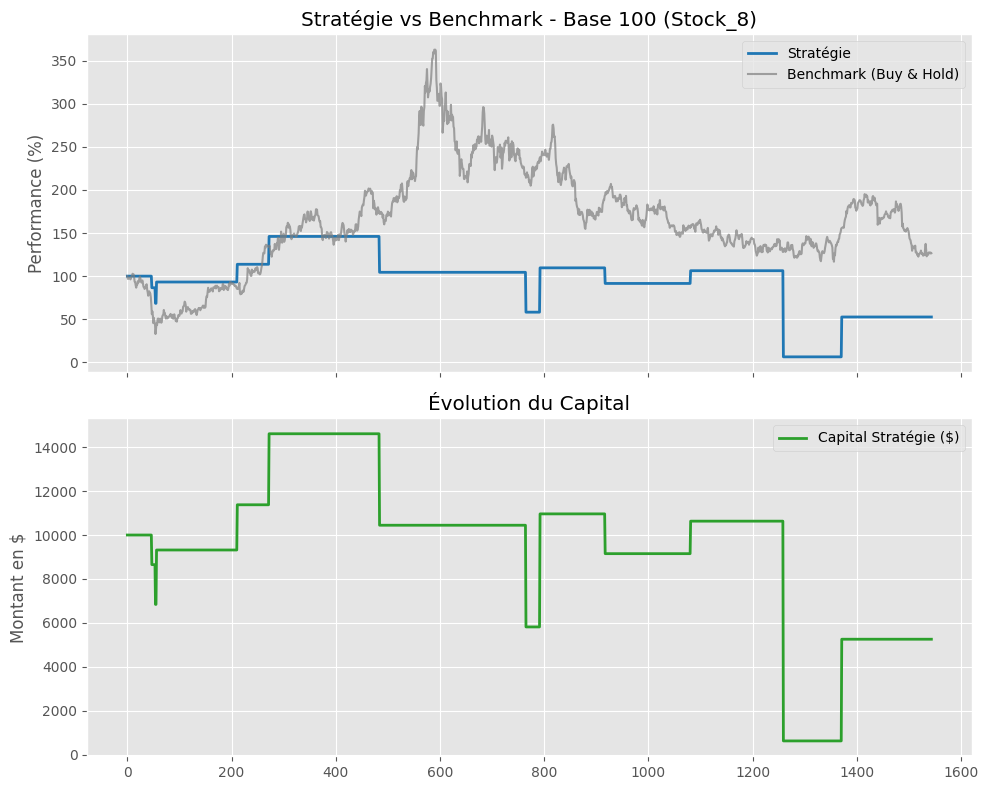

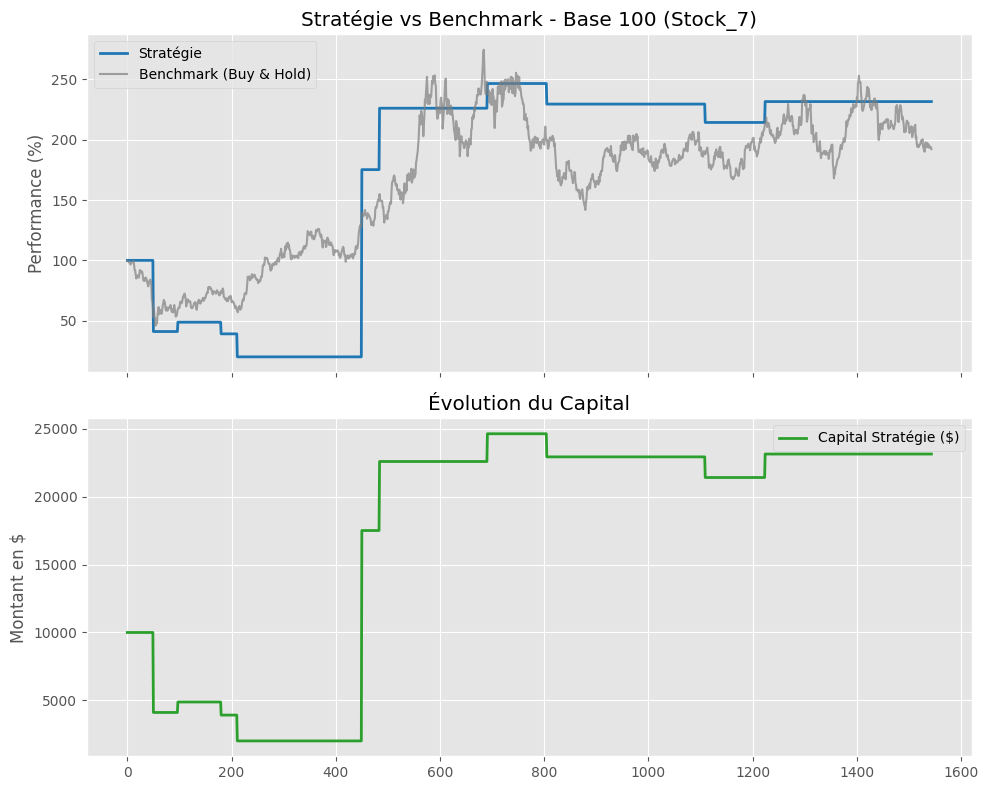

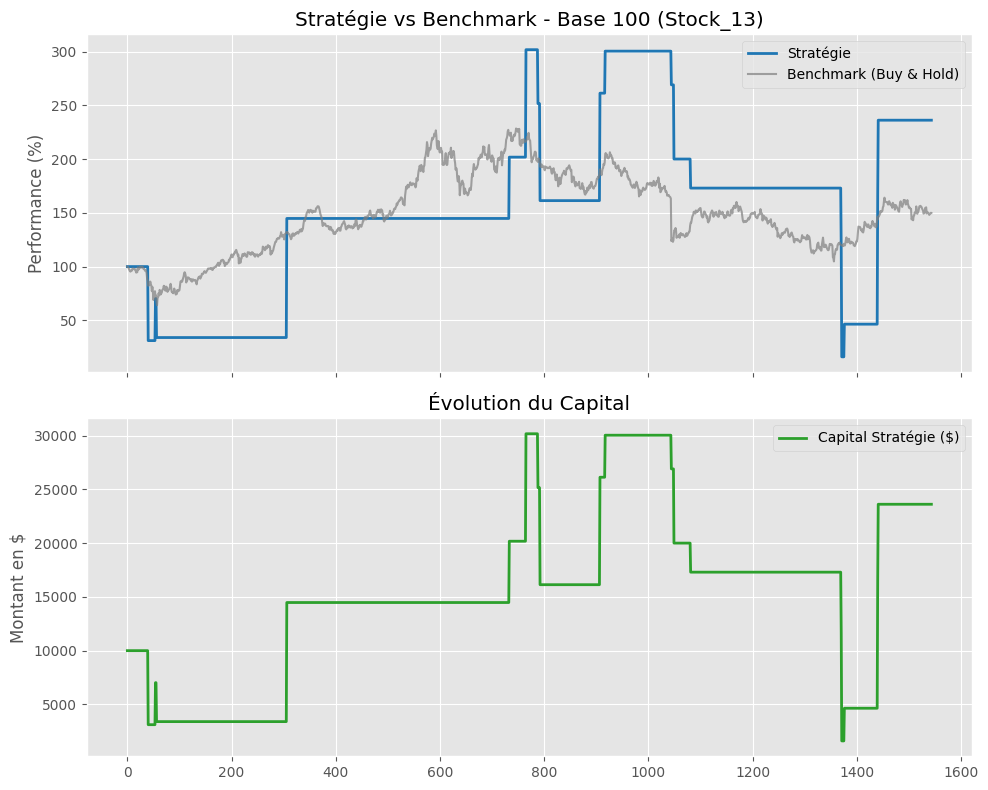

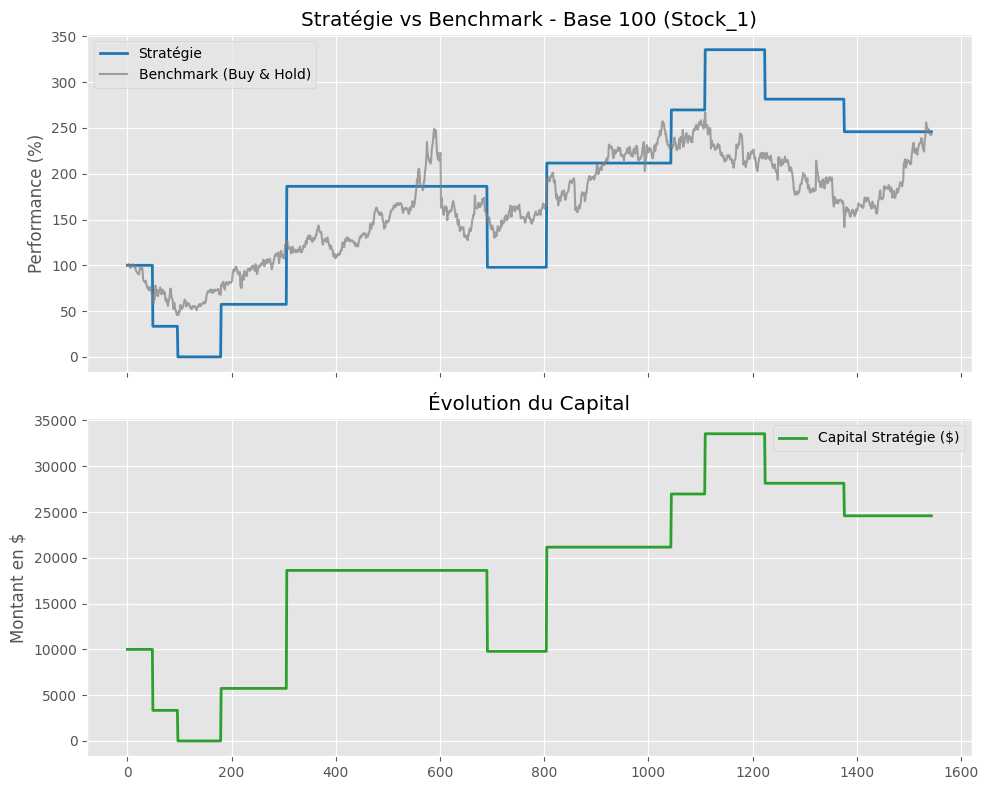

In [4]:
# -*- coding: utf-8 -*-
!pip install gurobipy
#!/usr/bin/env python3

import datetime as dt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import gurobipy as gp
import matplotlib

import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np
import pandas as pd
from scipy.stats import linregress
# from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller

import yfinance as yf
def preparer_donnees():
    print("Étape 1 : Téléchargement des données en cours...")
    tickers_mapping = {
        "Future": "ZW=F", "ETF_1": "3WHL.L", "ETF_2": "WEAT",
        "Stock_1": "ANDE", "Stock_2": "MGPI", "Stock_3": "SEB",
        "Stock_5": "AGCO", "Stock_6": "FMC", "Stock_7": "CF",
        "Stock_8": "MOS", "Stock_9": "DE", "Stock_10": "NTR",
        "Stock_11": "CTVA", "Stock_12": "BG", "Stock_13": "ADM"
    }

    data = yf.download(list(tickers_mapping.values()), start="2020-01-01", end="2025-12-31")
    data.ffill(inplace=True)

    print("Étape 2 : Formatage du tableau...")
    flat_columns = []
    for col in data.columns:
        variable = col[0]
        ticker = col[1]
        friendly_name = [k for k, v in tickers_mapping.items() if v == ticker][0]
        flat_columns.append(f"{friendly_name}_{variable}")
    data.columns = flat_columns

    print("Étape 3 : Réorganisation et nettoyage (IQR)...")
    colonnes_ordonnees = []
    variables_voulues = ['Open', 'High', 'Low', 'Close', 'Volume']
    for actif in tickers_mapping.keys():
        for variable in variables_voulues:
            nom_colonne = f"{actif}_{variable}"
            if nom_colonne in data.columns:
                colonnes_ordonnees.append(nom_colonne)

    data = data[colonnes_ordonnees]

    for col in data.columns:
        if "Volume" in col:
            continue

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_basse = Q1 - 3 * IQR
        limite_haute = Q3 + 3 * IQR

        data[col] = np.where((data[col] < limite_basse) | (data[col] > limite_haute), np.nan, data[col])

    data.ffill(inplace=True)

    print("Étape 4 : Sauvegarde du fichier final dans la session Colab...")
    nom_fichier = "Dataset_Wheat_G13_Final_Cleaned.csv"
    data.to_csv(nom_fichier)
    print("Données prêtes !")


#matplotlib.use('Agg', force=True)

CROSSING_MEAN = 0.5
CROSSING_MAX = 2
LAMBDA = 0.5
ORIG_AMOUNT = 10000
SAVE_FILE = None
RISK_FREE_RATE = 4/(100)      # 4-week T-bill return rate
TX_COST = 0.001


"""
Elle crée des variables pour les positions à l'achat (long) et à la vente (short).
Elle définit ensuite l'objectif du modèle : maximiser les rendements tout en minimisant le risque (pénalisé par le facteur LAMBDA).
Enfin, elle impose des contraintes strictes, notamment le fait de ne pas dépasser le capital disponible,
en incluant minutieusement les frais de transaction (TX_COST).
"""
def build_prob_cons(longs, shorts, prices, expected_returns,
                     expected_risk, trading_weights, risk_vec,
                    index, LAMBDA, tc, betas):

    global CROSSING_MAX, CROSSING_MEAN

    # XXX: Make the model
    model = gp.Model('portfolio')

    # XXX: The weight vars to optimise
    lws = [model.addVar(name='l!%s!%s' % (v[0], v[1]), lb=0, ub=1)
           for v in longs]
    sws = [model.addVar(name='s!%s!%s' % (v[0], v[1]), lb=-1, ub=0)
           for v in shorts]
    model.update()              # Added the vars to the model
    # model.addVars(lws + sws)

    # print('lws: ', lws, 'sws: ', sws)

    # XXX: Get the expected returns for the currencies being traded
    return_vec = [None]*len(shorts)
    for i, v in enumerate(shorts):
        if v[1] == v[0].split('_')[1]:
            return_vec[i] = -expected_returns[v[0]][0]
        else:
            return_vec[i] = -expected_returns[v[0]][1]

    # XXX: Make the return part of the optimisation objective
    max_ret_s = np.array(sws).dot(np.array(return_vec).T)

    return_vec = [None]*len(longs)
    for i, v in enumerate(longs):
        if v[1] == v[0].split('_')[1]:
            return_vec[i] = expected_returns[v[0]][0]
        else:
            return_vec[i] = expected_returns[v[0]][1]

    # XXX: Make the return part of the optimisation objective
    max_ret_l = np.array(lws).dot(np.array(return_vec).T)
    max_ret = max_ret_s + max_ret_l
    # print('max_ret: ', max_ret)  # correct!

    # XXX: Make the risk part of the objective
    ws = [None]*len(risk_vec)
    # XXX: This one makes 2 vectors in the same order of weight
    # variables as the expected_risk matrix
    for j, (f, s) in enumerate(zip(sws, lws)):
        assert(f.VarName.split('!')[1] == s.VarName.split('!')[1])
        if f.VarName.split('!')[2] < s.VarName.split('!')[2]:
            ws[j] = np.array((f, s))
        else:
            ws[j] = np.array((s, f))
    assert(len(ws) == len(risk_vec))

    # XXX: Make the covariance part of the matrix -ve, because of shorts
    # print(risk_vec)
    for k in risk_vec:
        risk_vec[k].iat[0, 1] = -risk_vec[k].iat[0, 1]
        risk_vec[k].iat[1, 0] = -risk_vec[k].iat[1, 0]
    # print('after change: ', risk_vec)
    min_risk = np.sum([(ws[i].dot(r).dot(ws[i].T))
                       for i, r in enumerate(risk_vec.values())])
    # print('min_risk: ', min_risk)

    # XXX: The overall optimisation objective
    obj = max_ret - (LAMBDA*min_risk)
    # print('obj: ', obj)
    model.setObjective(obj, gp.GRB.MAXIMIZE)
    model.update()

    # XXX: Overall cash available constraint
    currs = [ll.VarName.split('!')[2] for ll in lws]
    currs += [ss.VarName.split('!')[2] for ss in sws]
    currs = set(currs)      # The currencies beind traded
    # print('curencies being traded: ', currs)
    c_cons = [None]*len(currs)
    for k, c in enumerate(currs):
        if tc:
            lws_tc = [l*(1+TX_COST) for l in lws]
            sws_tc = [s*(1-TX_COST) for s in sws]
            ws = [w for w in (lws_tc + sws_tc) if str(w).split('!')[2] == c]
        else:
            ws = [w for w in (lws + sws) if w.VarName.split('!')[2] == c]
        c_cons[k] = (1-np.sum(trading_weights[c] + ws) >= 0)
        model.addConstr(c_cons[k])

    # print('Cash constraint:')
    # [print(c) for c in c_cons]
    # XXX: Price constraint
    # print('Price constraint')
    # [print(p) for p in p_cons]

    #on ajoute les contraintes sommes des beta = 0
    beta_expr = gp.LinExpr()


    for ll in lws:# on ajoute le bêta de la position longue
        lindex = ll.VarName.split('!')[2]# Récupère l'ID de l'actif (ex: '1' pour ETF_1)
        beta_expr += ll * betas[str(lindex)]# On multiplie le poids (ll) par le Beta de cet actif


    for ss in sws:# pareil pr la position courte
        sindex = ss.VarName.split('!')[2]
        beta_expr += ss * betas[str(sindex)]

    # On force la somme totale à être égale à zéro
    model.addConstr(beta_expr == 0)

    return model, zip(lws, sws)

# XXX: Simulate trading. Variable spread_dates has the common dates for
# all spreads to be traded.

"""
À chaque itération, elle vérifie si une position est déjà ouverte.
Si le Z-score est revenu vers zéro, elle clôture la position et enregistre les profits ou pertes.
Si aucune position n'est ouverte et qu'un Z-score dépasse un seuil extrême (souvent 3 écarts-types),
elle identifie une opportunité de marché. Elle appelle alors Gurobi (via build_prob_cons) pour calculer les poids idéaux,
ouvre la position, met à jour le capital et calcule à la fin les métriques de performance comme le ratio de Calmar.
"""
def simulate_trade(spreads, sigma3, lookup, spread_dates,
                   expected_returns, expected_risk, prices,
                   start, ed, zscores, tc,betas):

    global LAMBDA, MAKE_SLICE, SLICE_START, SLICE_END,trades_total2

    # XXX: The required prices
    prices = [price[price['Date'].isin(spread_dates)]['Close'].to_numpy()
              for price in prices]

    trades_total2 = pd.DataFrame(columns=['pair', 'ot', 'ct', 'wsl', 'wss', 'wcl', 'wcs'])#manquant dans le code original
    # pair : nom du spread tradé
    # ot   : Heure d'ouverture (Opening Time)
    # ct   : Heure de fermeture (Closing Time)
    # wsl  : Poids d'achat initial (Weight Start Long)
    # wss  : Poids de vente initial (Weight Start Short)
    # wcl  : Poids d'achat final (Weight Close Long)
    # wcs  : Poids de vente final (Weight Close Short)


    # XXX: 7235--24186 is for CAD-GBP-USD (5 minutes)
    # max_p_index = np.min([np.argmax(p[0:24186]) for p in prices])
    max_p_index = 0 if start is None else start
    end_p_index = spread_dates.shape[0] if ed is None else ed
    # XXX: Dates:
    start_d = dt.datetime.fromtimestamp(spread_dates[max_p_index])
    end_d = dt.datetime.fromtimestamp(spread_dates[end_p_index-1])
    start_date = dt.datetime.fromtimestamp(
        spread_dates[max_p_index]).strftime('%Y-%m-%d')
    end_date = dt.datetime.fromtimestamp(
        spread_dates[end_p_index-1]).strftime('%Y-%m-%d')
    print('START DATE: ', start_date)
    print('END DATE: ', end_date)
    trading_days = (end_d - start_d).days
    trading_days = 1 if trading_days <= 0 else trading_days
    print('# of days: ', trading_days)

    # raise Exception
    for p in prices:
        assert(spread_dates.shape[0] == len(p))

    trading_weights = {k: [] for k in lookup.keys()}
    trading_indices = {k: [max_p_index] for k in lookup.keys()}

    # XXX: Only one open position/spread at any given time
    open_positions = {k: None for k in spreads.columns}
    # open_trades = {k: None for k in spreads.columns}

    # XXX: Using X units of currency for each trade max
    orig_amount = {k: ORIG_AMOUNT for k in lookup.keys()}

    TOTAL = {k: 0 for k in spreads.columns}
    # XXX: Go through dates one by one (general case)
    # for i in range(max_p_index, spread_dates.shape[0]):

    # XXX: Best case
    for i in range(max_p_index+1, end_p_index):

   # print(open_positions)
        # XXX: Close any open position
        for k in open_positions.keys():

            if ((open_positions[k] is not None) and abs(zscores[k][i]) < CROSSING_MEAN):
                TOTAL[k] += 1
                Ethl = open_positions[k][0]
                Eths = open_positions[k][1]
                lindex = open_positions[k][2]
                sindex = open_positions[k][3]
                ps = prices[int(sindex)][i] * (1 - TX_COST if tc else 1)
                pl = prices[int(lindex)][i] * (1 + TX_COST if tc else 1)
                ws = -1 * (abs(Eths) * ps) / orig_amount[sindex]
                wl = (Ethl * pl) / orig_amount[lindex]
                trading_weights[sindex].append(-ws)
                trading_weights[lindex].append(-wl)

                # XXX: Append long and short too
                # trading_sws[sindex].append(ws)
                # trading_lws[lindex].append(wl)

                # XXX: For plotting
                trading_indices[sindex].append(i)
                trading_indices[lindex].append(i)

                # Fill closing details into trades_total
                #assert(len(trades_total[(trades_total['ct'].isna()) & (trades_total['pair']==k)]['ot']) <= 1)
                #trades_total.loc[(trades_total['ct'].isna()) & (trades_total['pair']==k), ['ct', 'pcl', 'pcs']] = [spread_dates[i-1], pl, ps]

                assert(len(trades_total2[(trades_total2['ct'].isna()) & (trades_total2['pair'] == k)]['ot']) <= 1)
                trades_total2.loc[(trades_total2['ct'].isna()) & (trades_total2['pair'] == k), ['ct', 'wcl', 'wcs']] = [spread_dates[i], wl, ws]

                # XXX: Position closed
                open_positions[k] = None
                # print('ps: %f, ws: %f, pl: %f, wl: %f, Eth: %f' %
                #       (ps, ws, pl, wl, Eth))

        # XXX: Get the longs and the shorts
        longs = list()
        shorts = list()
        risk_vec = dict()
        for s in spreads.columns:
            if (abs(zscores[s][i]) > sigma3[s] and (open_positions[s] is None)):
                risk_vec[s] = expected_risk[s]
                skeys = s.split('_')
                if zscores[s][i] > 0:
                    # if spreads[s][i] > 0:
                    # XXX: Short first
                    shorts.append((s, skeys[1]))
                    # XXX: Long second
                    longs.append((s, skeys[2]))
                else:
                    # XXX: Short second
                    shorts.append((s, skeys[2]))
                    # XXX: Long first
                    longs.append((s, skeys[1]))

        # XXX: DEBUG
        # if(len(longs) >= 2):
        #     print('GREAT! i, longs, shorts: ', i, longs, shorts)
        assert(len(longs) == len(shorts))
        if (len(longs) > 0):
            # print('longs: ', longs, 'shorts:', shorts)
            # LAMBDA = 1       # 1.0 is good enough
            problem, lsws = build_prob_cons(longs, shorts,
                                            prices, expected_returns,
                                            expected_risk,
                                            trading_weights, risk_vec, i,
                                            LAMBDA, tc,betas)
            problem.Params.OutputFlag = 0
            # problem.write('problem_%d.lp' % i)

            problem.optimize()

            if problem.status == gp.GRB.INFEASIBLE:
                continue

            # XXX: Open trade positions and weights
            for ll, s in lsws:
                # XXX: ETH to buy (long)
                lindex = ll.VarName.split('!')[2]
                sindex = s.VarName.split('!')[2]
                ps = prices[int(sindex)][i]*(1-TX_COST if tc else 1)
                pl = prices[int(lindex)][i]*(1+TX_COST if tc else 1)
                Ethl = (orig_amount[lindex]*ll.X)/pl   # Eth to buy
                Eths = (orig_amount[lindex]*s.X)/ps    # Eth to sell
                # XXX: Handling precision
                Ethl = float('%0.6f' % Ethl)
                Eths = float('%0.6f' % Eths)
                # print('pl: %f, wl: %f, ps: %f, ws: %f, Ethl: %f, Eths: %f' %
                #       (pl, ll.X, ps, s.X, Ethl, Eths))


                # XXX: Add the computed weights to the weight dictionary
                trading_weights[lindex].append(ll.X)
                trading_weights[sindex].append(s.X)

                # XXX: Trade (Open position)
                assert(ll.VarName.split('!')[1] == s.VarName.split('!')[1])
                pair_name = ll.VarName.split('!')[1]
                open_positions[pair_name] = (Ethl, Eths, lindex, sindex)

                nouveau_trade = pd.DataFrame([{'pair': pair_name,'ot': spread_dates[i],
                                               'ct': np.nan,'wsl': ll.X,'wss': s.X}])
                trades_total2 = pd.concat([trades_total2, nouveau_trade], ignore_index=True)

                # XXX: For plotting
                trading_indices[sindex].append(i)
                trading_indices[lindex].append(i)

    # print('TOTAL trades: ', TOTAL)
    # print('open positions: ', open_positions)
    # print('max index: ', max_p_index)
    # [print(trading_indices[k][-1]) for k in trading_weights.keys()]

    for k in open_positions.keys():
        if open_positions[k] is not None:
            lkey = open_positions[k][2]
            skey = open_positions[k][3]
            # XXX: Drop the last weights from lkey and skey
            trading_weights[lkey] = trading_weights[lkey][:-1]
            trading_weights[skey] = trading_weights[skey][:-1]
            trading_indices[lkey] = trading_indices[lkey][:-1]
            trading_indices[skey] = trading_indices[skey][:-1]
            # XXX: Close the position
            open_positions[k] = None

    # print('open positions closed: ', open_positions)
    # assert len(trading_lws) == len(trading_sws)

    # XXX: Total profit/loss
    fig, ax = plt.subplots(nrows=2, sharex=True)

    df_vals = pd.DataFrame()


    all_vals = {}
    for k in lookup.keys():
        if len(trading_weights[k]) % 2 != 0:
            trading_weights[k] = trading_weights[k][:-1]
            trading_indices[k] = trading_indices[k][:-1]

        pl = pd.Series(trading_weights[k]).cumsum()
        ones = np.ones(len(pl))
        val = (ones - pl) * orig_amount[k]
        val = list(val)
        val.insert(0, orig_amount[k])

        t_ds = pd.DataFrame(columns=['Date', 'val'])
        t_ds['Date'] = spread_dates
        for j, idx in enumerate(trading_indices[k]):
            t_ds.loc[idx, 'val'] = val[j]
        t_ds = t_ds.ffill()
        all_vals[k] = t_ds['val'][max_p_index:end_p_index].astype(float).values

    # Somme de toutes les equity curves = valeur réelle du portefeuille
    portfolio_val = np.sum(list(all_vals.values()), axis=0)

    # Benchmark : Buy & Hold de chaque actif (somme)
    portfolio_bh = np.zeros(end_p_index - max_p_index)
    for k in lookup.keys():
        buyqty = orig_amount[k] / prices[int(k)][max_p_index] * (1 - TX_COST if tc else 1)
        bh_curve = prices[int(k)][max_p_index:end_p_index] * buyqty
        portfolio_bh += bh_curve

    total_capital = ORIG_AMOUNT * len(lookup)

    afficher_reporting_complet(
        "PORTEFEUILLE TOTAL", "all",
        list(portfolio_val), list(portfolio_bh),
        trades_total2, RISK_FREE_RATE
    )

    # Aussi afficher les résultats par actif individuellement
    for k in lookup.keys():
        buyqty = orig_amount[k] / prices[int(k)][max_p_index] * (1 - TX_COST if tc else 1)
        bh_k = prices[int(k)][max_p_index:end_p_index] * buyqty
        afficher_reporting_complet(
            lookup[k], k,
            list(all_vals[k]), list(bh_k),
            trades_total2, RISK_FREE_RATE
        )
"""
transforme les identifiants mathématiques des paires en noms de devises lisibles pour les graphiques
"""
def keytoCUR(key, lookup):
    keys = key.split('_')
    return '_'.join([keys[0], lookup[keys[1]], lookup[keys[2]]] + keys)

"""
calcule les rendements logarithmiques moyens de chaque actif
"""
def get_expected_returns(dfs):
    # First compute the log returns for the dfs
    rets = [df['Close'].transform(np.log).diff().dropna()
            for df in dfs]
    return rets

"""
calcule les matrices de covariance entre toutes les paires d'actifs
sert a évaluer le risque de mouvements conjoints
"""
def pairwise_cov_matrices(dfs):
    # XXX: First get the log returns for each day
    rets = [df['Close'].transform(np.log).diff() for df in dfs]
    rets = [pd.DataFrame({'Date': d['Date'], 'Close': r})
            for d, r in zip(dfs, rets)]
    rets = [r.dropna() for r in rets]

    # XXX: Now do pairwise convariane matrices
    covdf = dict()
    for i in range(len(rets)):
        idates = set(rets[i]['Date'])
        for j in range(i+1, len(rets)):
            cdf = pd.DataFrame()
            jdates = set(rets[j]['Date'])
            cdates = jdates.intersection(idates)

            # XXX: Take the common dates from rets
            cdfi = rets[i][rets[i].Date.isin(cdates)]

            cdfj = rets[j][rets[j].Date.isin(cdates)]
            cdf['Close_%d' % i] = cdfi['Close'].to_numpy()
            cdf['Close_%d' % j] = cdfj['Close'].to_numpy()

            covdf['s_%d_%d' % (j, i)] = cdf.cov()
    return covdf


# XXX: oc_dates is a dict of list of tuples

"""
fait la moyenne de ces durées(get_expected_time_to_mean) pour estimer le temps d'immobilisation du capital pour chaque transaction
"""


def get_expected_time_to_mean(oc_dates):
    diff = {}
    valid_diffs = []
    for k, v in oc_dates.items():
        if len(v) > 0:
            d = np.mean([vv[1] - vv[0] for vv in v])  # maintenant en jours de trading
            diff[k] = d
            valid_diffs.append(d)

    default = np.mean(valid_diffs) * 10 if valid_diffs else 252  # 252 jours de trading/an
    for k, v in oc_dates.items():
        if len(v) == 0:
            diff[k] = default

    return pd.Series(diff)
# get_close_date(index, pair, spreads, spread_dates, zscores)

"""
calcule virtuellement combien de temps il faudra pour que l'écart revienne à son équilibre
"""
def get_close_date(start, spread, spreads, spread_dates, zscores):
    # get the std
    #dev = spreads[spread].std(axis=0)
    # get in timestamp
    toret = spread_dates[start]
    # maximum index
    index = spreads.shape[0]
    for i in range(start, spreads.shape[0]):
        # XXX: Falls to within 1/2 std-dev of the spread then close
        # From the current index loop to the end, wait when spreads become small
        if(abs(zscores[spread][i]) < CROSSING_MEAN):
            # record closing timestamp
            toret = spread_dates[i]
            index = i
            break

    return index, toret

# XXX: spread_dates is a numpy array of common dates
"""
Elle compile les rendements moyens,
les matrices de covariance et le temps de retour à la moyenne pour calculer très exactement l'espérance de gain (expected_returns)
et l'espérance de risque (expected_risk) de chaque paire. Une fois ces paramètres financiers calibrés,
elle déclenche la simulation de trading.
"""
def sigma3(dfs, spreads, lookup, spread_dates, start, end, zscores, tc):
    # XXX: Get everything ready to compute the open position

    # XXX: Vector of Expected returns for each currency anchored to ETH
    ret_vec = get_expected_returns(dfs)
    # var_vec = [v.var() for v in ret_vec]
    ret_vec = [v.mean() for v in ret_vec]
    # print('log returns: ', ret_vec)

    # XXX: Get the mean of the different spreads
    # means = spreads.mean(axis=0)
    stds = spreads.std(axis=0)
    sigma3 = pd.Series(CROSSING_MAX, index=spreads.columns)

    open_close_dates = {s: list() for s in spreads.columns}
    c_index = {s: -1 for s in spreads.columns}
    for i in range(spreads.shape[0]):
        for s in spreads.columns:
            # XXX: For each spread do the following
            # if((abs(spreads[s][i]) > sigma3[s]) and (i > c_index[s])):
            if((abs(zscores[s][i]) > sigma3[s]) and (i > c_index[s])):
                ci, cdate = get_close_date(i, s, spreads, spread_dates,
                                           zscores)
                c_index[s] = ci  # setting the close index
                # XXX: It is possible that it never closes at all!
                # We only consider for orders that closed in the future, otherwise not even record it.
                if cdate > spread_dates[i]:
                    open_close_dates[s].append((i, ci))

    # XXX: Expected time to revert to mean for any spread
    time_to_mean_vec = get_expected_time_to_mean(open_close_dates)
    # print('Time to mean:', time_to_mean_vec)

    # XXX: Now get the covariance matrices
    cov_matrices = pairwise_cov_matrices(dfs)
    # print('Pairwise covariance matrices')
    # for k, v in cov_matrices.items():
    #     print(k, ":", v)
    # XXX: DEBUG -- not exactly the same, but close enough
    # print('var_vec:', var_vec)

    # XXX: The total expected return =
    # Expected[ticks]*Expected[change/tick] for each spread to be
    # traded.
    expected_returns = pd.DataFrame()
    for s in time_to_mean_vec.index:
        keys = s.split('_')
        if not tc:
            # without transaction cost
            expected_returns[s] = [
                ret_vec[int(keys[1])]*time_to_mean_vec[s],
                ret_vec[int(keys[2])]*time_to_mean_vec[s]
            ]
        else:
            # have to consider the return can be positive and negative
            expected_returns[s] = [
                ret_vec[int(keys[1])]*time_to_mean_vec[s] - TX_COST*abs(ret_vec[int(keys[1])]*time_to_mean_vec[s]),
                ret_vec[int(keys[2])]*time_to_mean_vec[s] - TX_COST*abs(ret_vec[int(keys[2])]*time_to_mean_vec[s])
            ]
    # print(expected_returns)

    # XXX: Expected risk = Covariance matrix * Expected time to mean
    expected_risk = dict()
    for s in time_to_mean_vec.index:
        expected_risk[s] = cov_matrices[s]*time_to_mean_vec[s]
    # print('Expected Risk')
    # for k, v in expected_risk.items():
    #     print(k, ":", v)


    #calcul des betas
    returns_list = get_expected_returns(dfs)

    f_returns = returns_list[0]# correspond au future
    f_var = f_returns.var()

    betas = {}
    for idx, ret_series in enumerate(returns_list):
        cov = ret_series.cov(f_returns)
        betas[str(idx)] = cov / f_var

        print(f"Beta:{betas[str(idx)]:.4f}")


    # XXX: Simulate trading
    simulate_trade(spreads, sigma3, lookup, spread_dates,
                   expected_returns, expected_risk, dfs, start, end,
                   zscores, tc,betas)


# XXX: Main function for trading
"""
charge les fichiers historiques de prix (CSV) et s'assure qu'ils sont parfaitement alignés sur les mêmes dates,
calcule les écarts de prix (les "spreads") par régression linéaire,
test statistique de Dickey-Fuller Augmenté (adfuller) pour s'assurer que les paires étudiées sont bien co-intégrées,
calcule les Z-scores
"""
# XXX: Main function for trading
def arbitrage_trade(fileName, lookup, start, end, dofuller=True, tc=False):

    df = pd.read_csv(fileName)

    """
    # XXX: Get equal dated lists
    # Iterate all the csv files, find minimum length of csv
    while(True):
        # Choose the eth-currency pair with minimum length
        base = min([(i, len(dfs[i])) for i, df in enumerate(dfs)], key=lambda x: x[1])[0]
    # [(i, len(dfs[i])) for i, df in enumerate(dfs)]
    # key=lambda x: x[1]
        # Iilter date from every csv to make it within the date of minimum length base. Each df may have less days compare to the base ones.
        dfs = [df[df.Date.isin(dfs[base].Date)] for i, df in enumerate(dfs)]
        # Iterate all csv, set the days count in every df as an iterable. If the iterable has only one length then break
        if (len(set([df.shape[0] for df in dfs]))) == 1:
            break
        # Repeat the loop, goes back and find df with fewer content
    """
    # XXX: Make a single dataframe with all required data
    df['Date'] = pd.to_datetime(df['Date'])

    # On convertit ensuite proprement en Timestamp pour le reste de votre algorithme
    df['Date'] = df['Date'].apply(lambda x: int(x.timestamp()))
    spread_dates = df['Date'].to_numpy()

    odfs = []
    dicts = {}
    for i in lookup.keys():
        nom_actif = lookup[i]
        col_name = f"{nom_actif}_Close"

        temp_df = df[['Date', col_name]].copy()
        temp_df.columns = ['Date', 'Close']
        odfs.append(temp_df)

        dicts[f'Close_{i}'] = df[col_name].to_numpy()

    dfs = pd.DataFrame(data=dicts)

    # XXX: Plot the close price for all series
    # for d in dfs.columns:
    #     plt.plot(dfs[d][30500:31000], label=lookup[d.split('_')[1]])
    #     plt.legend()
    # plt.show(block=True)
    # raise Exception

    # XXX: Now start computing the spreads
    # XXX: First compute the correlation
    # alert if correlation less than 0.8, it is same ETH against all USD, CAD and GBP
    corrdf = dfs.corr()
    #la correlation entre les etf ets stocks seras jamais aussi forte
    #if (not corrdf.apply(lambda x: x > 0.99).all(axis=None)):
    #   raise Exception(corrdf)

    dfs_log = dfs.transform(np.log)
    spreads = pd.DataFrame()
    cols = dfs_log.columns
    # XXX: Compute the spreads in log space
    for i in range(dfs_log.shape[1]):
        for j in range(i+1, dfs_log.shape[1]):
            res = linregress(dfs_log[cols[i]], dfs_log[cols[j]])
            X = (dfs_log[cols[j]] - ((dfs_log[cols[i]]*res.slope) + res.intercept))
            # XXX: Check adfuller test -- for speed no need to
            if dofuller:
                _, pvalue, _, _, _, _ = adfuller(X, regression='ct')
                if pvalue < 0.3:
                    spreads['s_%d_%d' % (j, i)] = X
            else:
                spreads['s_%d_%d' % (j, i)] = X

    # _, ax = plt.subplots(nrows=2)
    # dfs.plot(ax=ax[0])

    # XXX: Compute the z-score for the spreads
    zscores = pd.DataFrame(columns=spreads.columns)
    for k in spreads.columns:
        zscores[k] = (spreads[k]-spreads[k].mean())/spreads[k].std(ddof=0)

    for i in spreads.columns:
        plt.plot(spreads[i], label=keytoCUR(i, lookup))

    plt.legend()

    # XXX: DEBUG histogram of spreads (is it normal?)
    # for s in spreads.columns:
    #     spreads[s].plot.hist(bins=100, legend=True)
    #     plt.show(block=True)

    # XXX: 3 sigma trading
    sigma3(odfs, spreads, lookup, spread_dates, start, end, zscores, tc)

    # leg = [keytoCUR(c, lookup) for c in spreads.columns]
    # markers = ['*', 'H', '^', '2', '1', '3', '4', '<', '>', '8', 's',
    #            'h', '+', 'o', 'P', 'X']
    # for i, s in enumerate(spreads.columns):
    #     plt.plot(range(len(spreads[s])), spreads[s], marker=markers[i],
    #              label=leg[i])
    # plt.legend()
    # plt.show(block=True)

    # XXX: Will most likely need both Wiener process + Poisson Jump

def auto_select_assets(fileName, anchor_name='Future', num_assets=4):
    df = pd.read_csv(fileName)

    # Identifier les colonnes
    close_cols = [col for col in df.columns if col.endswith('_Close')]
    prefixes = [col.replace('_Close', '') for col in close_cols]

    if anchor_name not in prefixes:
        return None

    candidates = [p for p in prefixes if p != anchor_name]

    df_log = np.log(df[close_cols])
    anchor_col = f"{anchor_name}_Close"

    p_values = {}

    #test de cointegration (Dickey-Fuller)
    for cand in candidates:
        cand_col = f"{cand}_Close"
        res = linregress(df_log[anchor_col].dropna(), df_log[cand_col].dropna())
        spread = df_log[cand_col] - (res.slope * df_log[anchor_col] + res.intercept)
        _, pval, _, _, _, _ = adfuller(spread.dropna(), regression='ct')
        p_values[cand] = pval

    # Classement par p-value
    sorted_candidates = sorted(p_values.items(), key=lambda item: item[1])

    # Création dynamique du dictionnaire lookup
    lookup = {'0': anchor_name}
    print("MEILLEURS ACTIFS")
    for i, (cand, pval) in enumerate(sorted_candidates[:num_assets]):
        idx = str(i + 1)
        lookup[idx] = cand
        print(f"Actif {idx}: {cand} (p-value: {pval:.4f})")

    return lookup

def do_wheat_trading():
    fichier_donnees = 'Dataset_Wheat_G13_Final_Cleaned.csv'

    lookup = auto_select_assets(fileName=fichier_donnees, anchor_name='Future', num_assets=5)

    if lookup is None:
        return

    arbitrage_trade(fileName=fichier_donnees,lookup=lookup,
                    start=0, end=None,dofuller=True, tc=True)


def afficher_reporting_complet(nom_actif, asset_index,capital_strat, capital_bh, trades_df, rfr=0.04):
    """
    Génère un tableau de KPIs et des graphiques de performance.
    capital_strat et capital_bh doivent être des listes ou des pd.Series représentant le capital jour après jour.
    """
    # Conversion en Series Pandas pour faciliter les calculs
    cap_s = pd.Series(capital_strat)
    cap_bh = pd.Series(capital_bh)

    jours_totaux = len(cap_s)
    annualisation = 365 # Base annuelle calendaire

    # 1. Calcul des Rendements Quotidiens
    ret_s = cap_s.pct_change().fillna(0)
    ret_bh = cap_bh.pct_change().fillna(0)

    # 2. Calcul du CAGR (Compound Annual Growth Rate)
    ratio_s = cap_s.iloc[-1] / cap_s.iloc[0]
    if ratio_s > 0:
        cagr_s = ratio_s ** (annualisation / jours_totaux) - 1
    else:
        cagr_s = -1.0  # perte totale

    ratio_bh = cap_bh.iloc[-1] / cap_bh.iloc[0]
    if ratio_bh > 0:
        cagr_bh = ratio_bh ** (annualisation / jours_totaux) - 1
    else:
        cagr_bh = -1.0
    # 3. Calcul du Max Drawdown
    roll_max_s = cap_s.cummax()
    dd_s = (cap_s - roll_max_s) / roll_max_s
    max_dd_s = abs(dd_s.min())

    roll_max_bh = cap_bh.cummax()
    dd_bh = (cap_bh - roll_max_bh) / roll_max_bh
    max_dd_bh = abs(dd_bh.min())

    # 4. Calcul du Ratio de Sharpe
    vol_s = ret_s.std() * np.sqrt(annualisation)
    sharpe_s = (cagr_s - rfr) / vol_s if vol_s != 0 else 0

    vol_bh = ret_bh.std() * np.sqrt(annualisation)
    sharpe_bh = (cagr_bh - rfr) / vol_bh if vol_bh != 0 else 0

    # 5. Calcul du Ratio de Calmar
    calmar_s = cagr_s / max_dd_s if max_dd_s != 0 else 0
    calmar_bh = cagr_bh / max_dd_bh if max_dd_bh != 0 else 0

    # 6. Nombre total de trades (filtré pour l'actif en question)
    if not trades_df.empty:
        if asset_index == "all":
            nb_trades = len(trades_df)
        else:
            nb_trades = len(trades_df[trades_df['pair'].apply(
                lambda x: asset_index in x.replace('s_', '').split('_')
            )])
    else:
        nb_trades = 0

    # --- CRÉATION DU TABLEAU DE RÉSULTATS ---
    metrics = pd.DataFrame({
        "KPI": ["CAGR", "Max Drawdown", "Ratio de Sharpe", "Ratio de Calmar", "Total Trades"],
        "Stratégie": [f"{cagr_s*100:.2f} %", f"{max_dd_s*100:.2f} %", f"{sharpe_s:.2f}", f"{calmar_s:.2f}", nb_trades],
        "Buy & Hold": [f"{cagr_bh*100:.2f} %", f"{max_dd_bh*100:.2f} %", f"{sharpe_bh:.2f}", f"{calmar_bh:.2f}", "-"]
    })

    print(f"\n========== RÉSULTATS POUR {nom_actif} ==========")
    print(metrics.to_string(index=False))
    print("================================================\n")

    # --- CRÉATION DES GRAPHIQUES ---
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

    # Graphique 1 : Stratégie vs Buy & Hold (Base 100)
    ax1.plot(cap_s / cap_s.iloc[0] * 100, label='Stratégie', color='#1f77b4', linewidth=2)
    ax1.plot(cap_bh / cap_bh.iloc[0] * 100, label='Benchmark (Buy & Hold)', color='#7f7f7f', alpha=0.7)
    ax1.set_title(f'Stratégie vs Benchmark - Base 100 ({nom_actif})')
    ax1.set_ylabel('Performance (%)')
    ax1.legend()

    # Graphique 2 : Simulation du Capital (Valeur absolue)
    ax2.plot(cap_s, label='Capital Stratégie ($)', color='#2ca02c', linewidth=2)
    ax2.set_title('Évolution du Capital')
    ax2.set_ylabel('Montant en $')
    ax2.legend()

    plt.tight_layout()


def main():
    global SAVE_FILE
    global RISK_FREE_RATE
    global CROSSING_MAX
    global CROSSING_MEAN
    preparer_donnees()
    do_wheat_trading()
    plt.show()
    pass

if __name__ == '__main__':
    # matplotlib.use('Agg', force=True)
    plt.style.use('ggplot')
    main()